In [ ]:
import sympy.printing          # this build does not attach the submodule; torch expects it

import numpy as np
import torch
import torch.nn as nn
from einops import rearrange, reduce
from torchvision.models import resnet18, ResNet18_Weights



import os
import gc
import pickle
import itertools

import torch                        # import torch BEFORE cuML (nemi): CUDA/numba init order
import cuml 
import numpy as np
import pandas as pd
import psutil
from matplotlib import pyplot as plt
from IPython.display import display

from nemi import NEMI, SingleNemi
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import visualization.visualization as vis
from nemi import NEMI, SingleNemi    # cuML — must come after torch
from metrics import projection_metrics as pm
from metrics import kmeans_eval
from metrics import cluster_eval

try:
    import cupy as cp
except Exception:
    cp = None

try:
    import pynvml; pynvml.nvmlInit(); _NVML_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)
except Exception:
    _NVML_HANDLE = None

In [ ]:
s = SingleNemi(params={'device':'gpu','embedding_dict':{'n_components':3,'n_neighbors':15}}); s.fit_embedding(np.random.rand(500, 8).astype('float32')); print('ok')


In [ ]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="2_03",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

In [ ]:
raw = cutouts_dataset.RawCutouts.download(source, subset=False,
                                          subsample_per_chunk=64, num_sample_chunks=1, n_workers=4)

In [ ]:
patch_size = 8
EMBEDDING_DIMENSIONS = 3

In [ ]:
#import engineer_features.patch_features as ef

data_channels = ["Theta", "Salt", "Eta", "gradb2", "relative_vorticity","strain_mag", "strain_n", "strain_s", "divergence", "coriolis_f"]

dataset = raw.select(data_channels)

In [ ]:
# feats = dataset.get_patches(patch_size=patch_size, preproc=True)
# X = feats

In [ ]:
OMEGA        = 7.2921e-5
DIV_SIGNED   = ("relative_vorticity",)                          # signed f: cyclonic positive in both hemispheres
DIV_ABS      = ("strain_n", "strain_s", "divergence")           # |f|: strain stays positive, convergence stays convergence
N_NEIGHBORS  = (50, 100)
ALWAYS_LOAD  = ("gradb2", "coriolis_f")                         # colour source and f divisor, loaded whether or not listed


def _prepared(X, name, ix, cfg, lg, f_signed):
    """One channel of (N, H, W), after log / division by f."""
    if name == "gradb2":
        return lg
    a = X[:, ix[name]]
    if cfg.get("div_by_f") and name in DIV_SIGNED:
        return a / f_signed
    if cfg.get("div_by_f") and name in DIV_ABS:
        return a / np.abs(f_signed)
    return a


def build_patch_data(raw, cfg, equator_deg=5.0, block=256):
    """The patch matrix for one config, ready for a NEMI run.

    cfg is {"channels": [...], "patch_size": int, "div_by_f": bool, "name": str}.
    coriolis_f never enters the features; gradb2 and coriolis_f are always loaded so the
    colour and the divisor are available regardless of what is listed.  Channels are
    z-scored globally, one mean/std each, after the log and the f-division.

    Returns {"name", "params", "feature_channels", "X", "colour", "near_equator"},
    all rows in get_patches order.
    """
    for k in ("channels", "patch_size", "name"):
        if k not in cfg:
            raise ValueError(f"config missing '{k}': {cfg}")
    feat = [c for c in cfg["channels"] if c != "coriolis_f"]
    load = list(dict.fromkeys(feat + list(ALWAYS_LOAD)))
    ps = cfg["patch_size"]
    f_floor = 2 * OMEGA * np.sin(np.deg2rad(equator_deg))

    ds = raw.select(load)
    X = ds.X
    if X.shape[2] % ps or X.shape[3] % ps:
        raise ValueError(f"patch_size {ps} does not divide {X.shape[2:]}")
    ix = {c: ds.channel_names.index(c) for c in load}

    g = X[:, ix["gradb2"]]
    s = g[::max(1, len(g) // 64)]
    gfloor = float(s[s > 0].min()) if (s > 0).any() else 1e-20

    # pass 1: one mean/std per channel, over every pixel of every cutout
    cnt = 0
    s1 = np.zeros(len(feat)); s2 = np.zeros(len(feat))
    for i in range(0, len(X), block):
        cut = np.asarray(X[i:i + block], dtype="float32")
        f = cut[:, ix["coriolis_f"]]
        fs = np.where(f < 0, -1.0, 1.0) * np.maximum(np.abs(f), f_floor)
        lg = np.log10(np.where(cut[:, ix["gradb2"]] > 0, cut[:, ix["gradb2"]], gfloor))
        for c, name in enumerate(feat):
            a = _prepared(cut, name, ix, cfg, lg, fs).astype(np.float64)
            s1[c] += a.sum(); s2[c] += (a ** 2).sum()
        cnt += cut[:, 0].size
    mu = s1 / cnt
    sd = np.sqrt(np.maximum(s2 / cnt - mu ** 2, 0.0))

    # pass 2: z-score, patchify, and collect the colour + equator flag
    parts, colour, near_eq = [], [], []
    for i in range(0, len(X), block):
        cut = np.asarray(X[i:i + block], dtype="float32")
        f = cut[:, ix["coriolis_f"]]
        fs = np.where(f < 0, -1.0, 1.0) * np.maximum(np.abs(f), f_floor)
        lg = np.log10(np.where(cut[:, ix["gradb2"]] > 0, cut[:, ix["gradb2"]], gfloor))
        cols = []
        for c, name in enumerate(feat):
            a = (_prepared(cut, name, ix, cfg, lg, fs) - mu[c]) / (sd[c] + 1e-30)
            cols.append(rearrange(a, 'n (h p1) (w p2) -> (n h w) (p1 p2)', p1=ps, p2=ps))
        parts.append(np.hstack(cols).astype("float32"))
        colour.append(reduce(lg, 'n (h p1) (w p2) -> (n h w)', 'mean', p1=ps, p2=ps))
        near_eq.append(reduce((np.abs(f) < f_floor).astype("float32"),
                              'n (h p1) (w p2) -> (n h w)', 'max', p1=ps, p2=ps) > 0)

    out = {"name": cfg["name"], "params": dict(cfg), "feature_channels": feat,
           "X": np.ascontiguousarray(np.vstack(parts), dtype="float32"),
           "colour": np.concatenate(colour),
           "near_equator": np.concatenate(near_eq)}
    parts = None
    gc.collect()
    return out


def build_embeddings(raw, configs, n_components=3, min_dist=0.0, equator_deg=5.0,
                     fit_n=None, block=256, device="gpu", seed=0):
    """Two UMAP embeddings (n_neighbors 50 and 100) per config, over build_patch_data."""
    rng = np.random.default_rng(seed)
    results = []

    for cfg in configs:
        d = build_patch_data(raw, cfg, equator_deg=equator_deg, block=block)
        F, colour, near_eq = d["X"], d["colour"], d["near_equator"]

        idx = (np.sort(rng.choice(len(F), fit_n, replace=False))
               if fit_n and fit_n < len(F) else np.arange(len(F)))
        Xf = np.ascontiguousarray(F[idx], dtype="float32")
        F = d["X"] = None
        gc.collect()

        embs = {}
        for nn in N_NEIGHBORS:
            m = SingleNemi(params={"device": device,
                                   "embedding_dict": {"n_components": n_components,
                                                      "n_neighbors": nn,
                                                      "min_dist": min_dist}})
            m.fit_embedding(Xf)
            embs[nn] = np.asarray(m.embedding)
            m = None
            gc.collect()

        results.append({"name": d["name"], "params": d["params"],
                        "feature_channels": d["feature_channels"],
                        "dims": Xf.shape[1], "n_patches": len(colour), "fit_index": idx,
                        "colour": colour[idx], "near_equator": near_eq[idx],
                        "embeddings": embs})
        ps = cfg["patch_size"]
        print(f"{d['name']}\n    {len(d['feature_channels'])} channels x {ps*ps} px = "
              f"{Xf.shape[1]} dims | {len(colour):,} patches | fit on {len(Xf):,} | "
              f"{int(near_eq[idx].sum()):,} near-equator")
        Xf = None
        gc.collect()

    return results


def plot_embeddings(results, disp_n=60_000, point_size=0.5, alpha=0.25,
                    title_size=17, seed=0):
    """Two rows (n_neighbors 50 / 100) x one column per config, on a shared colour scale."""
    rng = np.random.default_rng(seed)
    rows, cols = len(N_NEIGHBORS), len(results)
    allc = np.concatenate([r["colour"] for r in results])
    lo, hi = np.nanpercentile(allc, [2, 98])

    fig = plt.figure(figsize=(6.0 * cols, 5.6 * rows))
    for c, r in enumerate(results):
        sub = rng.choice(len(r["colour"]), size=min(disp_n, len(r["colour"])), replace=False)
        v = r["colour"][sub]
        for k, nn in enumerate(N_NEIGHBORS):
            E = r["embeddings"][nn][sub]
            ax = fig.add_subplot(rows, cols, k * cols + c + 1, projection="3d")
            sc = ax.scatter(E[:, 0], E[:, 1], E[:, 2], c=v, cmap="viridis", vmin=lo, vmax=hi,
                            s=point_size, alpha=alpha, linewidths=0)
            ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
            if c == 0:
                ax.text2D(-0.08, 0.5, f"n_neighbors = {nn}", transform=ax.transAxes,
                          rotation=90, va="center", ha="center", fontsize=title_size - 2)
            if k == 0:
                ax.set_title(f"{r['name']}\n{r['dims']} dims, {r['n_patches']:,} patches",
                             fontsize=title_size, pad=14)
            if c == cols - 1 and k == 0:
                fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label="mean log10 gradb2")
    fig.tight_layout()
    plt.show()
    return fig

In [ ]:
import gc
import numpy as np
import torch
from einops import rearrange
from matplotlib import pyplot as plt

import dl_embedding.mae as mae


def preprocessed_cutouts(raw, cfg, equator_deg=5.0, block=256):
    """(N, C, H, W) cutouts after the standard preprocessing.

    gradb2 logged, kinematics divided by f when div_by_f (signed f for vorticity so
    cyclonic is positive in both hemispheres, |f| for strain and divergence so they
    keep their sign south of the equator), then one global mean/std per channel.
    """
    feat = [c for c in cfg["channels"] if c != "coriolis_f"]
    load = list(dict.fromkeys(feat + list(ALWAYS_LOAD)))
    f_floor = 2 * OMEGA * np.sin(np.deg2rad(equator_deg))

    ds = raw.select(load)
    X = ds.X
    ix = {c: ds.channel_names.index(c) for c in load}
    s = X[::max(1, len(X) // 64), ix["gradb2"]]
    gfloor = float(s[s > 0].min()) if (s > 0).any() else 1e-20

    cnt = 0
    s1 = np.zeros(len(feat)); s2 = np.zeros(len(feat))
    for i in range(0, len(X), block):
        cut = np.asarray(X[i:i + block], dtype="float32")
        f = cut[:, ix["coriolis_f"]]
        fs = np.where(f < 0, -1.0, 1.0) * np.maximum(np.abs(f), f_floor)
        lg = np.log10(np.where(cut[:, ix["gradb2"]] > 0, cut[:, ix["gradb2"]], gfloor))
        for c, name in enumerate(feat):
            a = _prepared(cut, name, ix, cfg, lg, fs).astype(np.float64)
            s1[c] += a.sum(); s2[c] += (a ** 2).sum()
        cnt += cut[:, 0].size
    mu = s1 / cnt
    sd = np.sqrt(np.maximum(s2 / cnt - mu ** 2, 0.0))

    out = np.empty((len(X), len(feat)) + X.shape[2:], dtype="float32")
    for i in range(0, len(X), block):
        cut = np.asarray(X[i:i + block], dtype="float32")
        f = cut[:, ix["coriolis_f"]]
        fs = np.where(f < 0, -1.0, 1.0) * np.maximum(np.abs(f), f_floor)
        lg = np.log10(np.where(cut[:, ix["gradb2"]] > 0, cut[:, ix["gradb2"]], gfloor))
        for c, name in enumerate(feat):
            out[i:i + block, c] = (_prepared(cut, name, ix, cfg, lg, fs) - mu[c]) / (sd[c] + 1e-30)
    return out, feat


def train_mae(raw, cfg, epochs=40, mask_ratio=0.75, val_frac=0.2, batch_size=64,
              equator_deg=5.0, block=256, seed=0, **mae_kwargs):
    """Preprocess the cutouts and train a multichannel ViT-MAE on them.

    Returns {"embedder", "images", "feature_channels", "params"} -- the trained
    MAEEmbedder plus the preprocessed cutouts it saw, so reconstructions can be
    drawn from the same array.
    """
    images, feat = preprocessed_cutouts(raw, cfg, equator_deg, block)
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(images))
    n_val = max(1, int(val_frac * len(images)))

    embedder = mae.MAEEmbedder(patch_size=cfg["patch_size"], mask_ratio=mask_ratio,
                               **mae_kwargs)
    print(f"{cfg['name']}\n    {images.shape} | {len(feat)} channels | "
          f"token {cfg['patch_size']} | train {len(images)-n_val} val {n_val}")
    embedder.fit(images[perm[n_val:]], val_images=images[perm[:n_val]],
                 epochs=epochs, batch_size=batch_size, seed=seed)
    gc.collect()
    return {"embedder": embedder, "images": images, "feature_channels": feat,
            "params": dict(cfg)}


def _unpatchify(x, model, grid):
    """(B, N, p*p*C) -> (B, C, H, W); inverse of PatchMAE.patchify."""
    p, c = model.patch_size, model.in_chans
    return rearrange(x, "b (gh gw) (p1 p2 c) -> b c (gh p1) (gw p2)",
                     gh=grid, p1=p, p2=p, c=c)


@torch.no_grad()
def show_reconstructions(trained, n_cutouts=3, channels=None, mask_ratio=None,
                         seed=0, panel=2.6):
    """Original | masked | reconstructed, one row per channel, one figure per cutout.

    The masked panel is what the encoder actually saw; the reconstruction pastes the
    decoder's prediction into the masked patches and keeps the visible ones, which is
    the standard MAE figure -- so agreement in the grey regions is the model working
    and agreement elsewhere is the input passing through.
    """
    emb, images, feat = trained["embedder"], trained["images"], trained["feature_channels"]
    model = emb.model
    if model is None:
        raise RuntimeError("train_mae must run before show_reconstructions")
    ratio = emb.mask_ratio if mask_ratio is None else mask_ratio
    show = list(channels) if channels else feat
    missing = [c for c in show if c not in feat]
    if missing:
        raise ValueError(f"channels not in the trained set: {missing}")

    rng = np.random.default_rng(seed)
    pick = rng.choice(len(images), size=min(n_cutouts, len(images)), replace=False)
    x = torch.from_numpy(images[pick]).to(emb.device)
    grid = model.grid

    torch.manual_seed(seed)
    latent, mask, ids_restore = model.forward_encoder(x, ratio)
    pred = model.forward_decoder(latent, ids_restore)              # (B, N, p*p*C)
    target = model.patchify(x)
    keep = (1.0 - mask).unsqueeze(-1)                              # 1 where the encoder saw it
    recon = _unpatchify(target * keep + pred * (1 - keep), model, grid).cpu().numpy()
    masked = _unpatchify(target * keep, model, grid).cpu().numpy()
    orig = x.cpu().numpy()

    for r, i in enumerate(pick):
        fig, axes = plt.subplots(len(show), 3, squeeze=False,
                                 figsize=(panel * 3, panel * len(show)))
        for k, name in enumerate(show):
            c = feat.index(name)
            lo, hi = np.percentile(orig[r, c], [2, 98])
            for j, (img, tag) in enumerate(((orig[r, c], "original"),
                                            (masked[r, c], f"masked {ratio:.0%}"),
                                            (recon[r, c], "reconstructed"))):
                ax = axes[k][j]
                ax.imshow(img, cmap="viridis", vmin=lo, vmax=hi)
                ax.set_xticks([]); ax.set_yticks([])
                if k == 0:
                    ax.set_title(tag, fontsize=11)
                if j == 0:
                    ax.set_ylabel(name, fontsize=10)
        fig.suptitle(f"cutout {int(i)}", y=1.001)
        fig.tight_layout(); plt.show()

In [ ]:
trained = train_mae(raw, data_channels_all, epochs=40)
show_reconstructions(trained, n_cutouts=3, channels=["gradb2", "Theta"])

In [12]:
#compare embeddings. 
channels = "channels"
patch_size = "patch_size"
div_by_f = "div_by_f"
name = "name"

data_channels_all = {channels : ["Theta", "Salt", "gradb2", "relative_vorticity","strain_n", "strain_s", "divergence"],
                     patch_size : 4,
                     div_by_f : True,
                     name : "PatchSize=4 Nondimensionalized Kinematics B and Scalars"
                    }

data_channels_all_8 = {channels : ["Theta", "Salt", "gradb2", "relative_vorticity","strain_n", "strain_s", "divergence"],
                     patch_size : 8,
                     div_by_f : True,
                     name : "PatchSize=8 Nondimensionalized Kinematics B and Scalars"
                    }

data_channels_ts = {channels : ["Theta", "Salt"],
                     patch_size : 4,
                     div_by_f : True,
                     name : "PatchSize=4 TandS"
                    }

data_channels_ts_8 = {channels : ["Theta", "Salt"],
                     patch_size : 8,
                     div_by_f : True,
                     name : "PatchSize=8 TandS"
                    }

B_scalars = {channels : ["Theta", "Salt", "gradb2"],
                     patch_size : 4,
                     div_by_f : True,
                     name : "PatchSize=4 B and Scalars"
                    }


B_scalars_8 = {channels : ["Theta", "Salt", "gradb2"],
                     patch_size : 8,
                     div_by_f : True,
                     name : "PatchSize=8 B and Scalars"
                    }

kinematics = {channels : ["relative_vorticity","strain_n", "strain_s", "divergence"],
                     patch_size : 4,
                     div_by_f : True,
                     name : "PatchSize=4 Nondimensionalized Kinematics"
                    }

kinematics_8 = {channels : ["relative_vorticity","strain_n", "strain_s", "divergence"],
                     patch_size : 8,
                     div_by_f : True,
                     name : "PatchSize=8 Nondimensionalized Kinematics"
                    }

configs = [data_channels_all, data_channels_all_8, B_scalars, B_scalars_8, kinematics, kinematics_8]

# results = build_embeddings(raw, configs, fit_n=None)


In [13]:
#plot_embeddings(results, disp_n=2_000_000, alpha=0.2)

In [14]:
# --- shared helpers -------------------------------------------------------
def _umap_configs(grid):
    """Full-factorial expansion of {param: [values]} -> dicts."""
    keys = list(grid)
    for vals in itertools.product(*(grid[k] for k in keys)):
        yield dict(zip(keys, vals))


def _free_gpu():
    """Drop references and return pooled GPU blocks between fits."""
    gc.collect()
    if cp is not None:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()


def _fit_embeddings(X, umap_params, n_components, device, n_runs):
    """Fit n_runs UMAP embeddings of X (embedding only, no clustering)."""
    embs = []
    for _ in range(n_runs):
        s = SingleNemi(params={"device": device,
                               "embedding_dict": {"n_components": n_components, **umap_params}})
        s.fit_embedding(X)
        embs.append(np.asarray(s.embedding))
        s = None
        _free_gpu()
    return embs


def _n_clusters(labels):
    """Cluster count, ignoring NaN/negative (-1) noise."""
    finite = np.asarray(labels, dtype=float)
    finite = finite[np.isfinite(finite)]
    finite = finite[finite >= 0]
    return int(finite.max()) + 1 if finite.size else 0


def gpu_used_gb():
    return pynvml.nvmlDeviceGetMemoryInfo(_NVML_HANDLE).used / 1e9 if _NVML_HANDLE is not None else float("nan")


def host_used_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9


# pod host memory cap (cgroup) -- context for the host_used_gb readings
try:    _host_cap = open("/sys/fs/cgroup/memory.max").read().strip()            # cgroup v2
except: _host_cap = open("/sys/fs/cgroup/memory/memory.limit_in_bytes").read()  # cgroup v1
print("host cap:", _host_cap)

host cap: 137438953472


In [15]:
def _cluster(embedding, clu_params, device):
    """Cluster an already-fitted embedding with NEMI's clusterer (no re-embedding).
    clu_params is a clustering_dict, e.g. {'method':'hdbscan','min_cluster_size':400}."""
    s = SingleNemi(params={"device": device, "clustering_dict": dict(clu_params)})
    s.embedding = np.asarray(embedding)
    return np.asarray(s.predict_clusters())


def _silhouette(embedding, labels, sample_size, seed):
    """Silhouette over the assigned points only; -1 noise is dropped rather than
    scored as a cluster."""
    keep = labels >= 0
    return kmeans_eval.silhouette(embedding[keep], labels[keep],
                                  sample_size=sample_size, seed=seed)


def run_embedding_sweep(patches, umap_grid, clustering_grid=None, *, n_runs=3,
                        n_components=3, device="gpu", sweep_size=50000,
                        metric_sample=3000, silhouette=False, k=pm.DEFAULT_K,
                        display_subsample=30000,
                        field=None, labels=None, save_path="embed_sweep.pkl",
                        seed=0, verbose=True):
    """Sweep UMAP params (embedding only) and, optionally, clustering params.

    Each UMAP config's embedding is fit once and scored with the projection metrics
    (trustworthiness, continuity, normalized_stress, and neighborhood_hit when
    ``labels`` is given).  If ``clustering_grid`` is given, every clustering config
    is run on that embedding and its cluster count + noise % recorded -- one result
    row per (UMAP x clustering) combination.

    clustering_grid MUST include 'method' (e.g. {'method':['hdbscan'],
    'min_cluster_size':[200,400], 'min_samples':[None]}).  None -> embedding only.

    silhouette : also score each clustering with the silhouette coefficient, over
    ``metric_sample`` points.  Needs labels, so it has no effect without a
    clustering_grid.

    Returns (results, panels).
    """
    rng = np.random.default_rng(seed)
    n = len(patches)
    fit_idx = (rng.choice(n, size=sweep_size, replace=False)
               if sweep_size and sweep_size < n else np.arange(n))
    Xfit  = patches[fit_idx]
    f_fit = None if field is None else np.asarray(field)[fit_idx]
    l_fit = None if labels is None else np.asarray(labels)[fit_idx]

    m_idx = rng.choice(len(Xfit), size=min(metric_sample, len(Xfit)), replace=False)
    Xm    = Xfit[m_idx]
    l_m   = None if l_fit is None else l_fit[m_idx]

    clu_configs = list(_umap_configs(clustering_grid)) if clustering_grid else [None]

    results, panels = [], []
    for umap_params in _umap_configs(umap_grid):
        print(f"GPU {gpu_used_gb():.2f}")
        if verbose:
            print(f"embedding {umap_params}")
        try:
            embs = _fit_embeddings(Xfit, umap_params, n_components, device, n_runs)
            E0   = embs[0]
            Em0  = E0[m_idx]

            proj = {"trustworthiness":   pm.trustworthiness(Xm, Em0, k),
                    "continuity":        pm.continuity(Xm, Em0, k),
                    "normalized_stress": pm.normalized_stress(Xm, Em0)}
            if l_m is not None:
                proj["neighborhood_hit"] = pm.neighborhood_hit(Em0, l_m, k)

            disp = (rng.choice(len(E0), size=min(len(E0), display_subsample), replace=False)
                    if display_subsample else slice(None))
            embs_disp = [e[disp] for e in embs]        # shared across clustering configs

            for clu_params in clu_configs:
                stat = {**umap_params, **(clu_params or {}), **proj}
                clusters_disp = None
                if clu_params is not None:
                    try:
                        lab = _cluster(E0, clu_params, device)
                        stat["found_k"] = _n_clusters(lab)
                        stat["noise_%"] = 100 * float(np.mean(lab < 0))
                        top, eff_k = cluster_eval.cluster_balance(lab[lab >= 0])
                        stat["top_cluster_%"] = 100 * top
                        stat["effective_k"]   = eff_k
                        if silhouette:
                            stat["silhouette"] = _silhouette(E0, lab, metric_sample, seed)
                        clusters_disp = lab[disp]
                    except Exception as e:
                        print(f"    clustering failed {clu_params}: {type(e).__name__}: {e}")
                    finally:
                        lab = None
                        _free_gpu()                    # <-- release GPU between clustering configs

                if verbose:
                    tag = "" if clu_params is None else f"{clu_params}  "
                    print("  " + tag + "  ".join(f"{kk}={vv:.3f}" for kk, vv in stat.items()
                                                 if isinstance(vv, float)))

                title = str(umap_params) + ("" if clu_params is None else f"\n{clu_params}")
                panels.append({"title": title,
                               "embs": embs_disp,                 # same object -> no copy
                               "field": None if f_fit is None else f_fit[disp],
                               "clusters": clusters_disp})
                results.append(stat)

            if save_path:
                with open(save_path, "wb") as fh:
                    pickle.dump({"results": results, "panels": panels}, fh)
        except Exception as e:
            print(f"  !! failed on {umap_params}: {type(e).__name__}: {e}")
        finally:
            _free_gpu()

    return results, panels

In [16]:
from sklearn.decomposition import PCA


def _frame_axes(ax, pts, dims, pct=1.0):
    """Clip axis limits to the central (100-2*pct)% per dim, so a few outliers
    don't zoom the whole cloud out.  pct<=0 disables."""
    if pct <= 0:
        return
    setters = [ax.set_xlim, ax.set_ylim] + ([ax.set_zlim] if dims == 3 else [])
    for d, setlim in enumerate(setters):
        lo, hi = np.percentile(pts[:, d], [pct, 100 - pct])
        if hi > lo:
            setlim(lo, hi)


def _view(e, dims):
    """Reduce an embedding to `dims` for DISPLAY ONLY -- PCA when it has more than
    `dims` components (e.g. an n_components sweep).  Metrics use the full embedding."""
    return PCA(n_components=dims).fit_transform(e) if e.shape[1] > dims else e


_SHORT = {"trustworthiness": "trust", "continuity": "cont",
          "normalized_stress": "stress", "neighborhood_hit": "nh",
          "found_k": "k", "noise_%": "noise%", "top_cluster_%": "top%",
          "effective_k": "eff_k", "silhouette": "sil"}


def _metric_label(res, per_line=None):
    """Recorded metrics as "trust=0.90  cont=0.80  ..."; per_line wraps onto several
    lines for captions narrower than the string (None = one line)."""
    parts = [(f"{s}={res[n]:.0f}" if n == "found_k" else f"{s}={res[n]:.2f}")
             for n, s in _SHORT.items() if n in res]
    per_line = per_line or len(parts) or 1
    return "\n".join("  ".join(parts[i:i + per_line]) for i in range(0, len(parts), per_line))


def _row_label(p, res):
    parts = _metric_label(res)
    return f"{p['title']}\n{parts}" if parts else p["title"]


def show_embedding_sweep(results, panels, *, dims=3, sort_by=None,
                         point_size=2, alpha=0.5, panel_size=4.5, clip_pct=1.0):
    """Grid of swept embeddings: one ROW per config, one COLUMN per ensemble member.

    Colouring: by cluster labels (discrete, -1 grey) when a panel has them,
    else by ``field`` (continuous), else plain.  Embeddings with more than `dims`
    components are PCA-reduced to `dims` for display only.  clip_pct clips each
    axis to that percentile range (0 = off)."""
    proj   = "3d" if dims == 3 else None
    n_runs = max(len(p["embs"]) for p in panels)
    n_rows = len(panels)

    fig, axes = plt.subplots(n_rows, n_runs, squeeze=False,
                             figsize=(panel_size * n_runs, panel_size * n_rows),
                             subplot_kw={"projection": proj})
    fig.subplots_adjust(left=0.26, hspace=0.15, wspace=0.05)

    for r, (p, res) in enumerate(zip(panels, results)):
        clusters = p.get("clusters")
        field    = p.get("field")
        if clusters is not None:
            color, cmap, norm = clusters, *vis._cluster_cmap_norm(clusters)
        elif field is not None:
            color, cmap, norm = field, "viridis", None
        else:
            color, cmap, norm = None, None, None

        sc = None
        for j, e in enumerate(p["embs"]):
            ev = _view(e, dims)                       # PCA -> dims for display only
            ax = axes[r][j]
            sc = ax.scatter(*[ev[:, d] for d in range(dims)], c=color, cmap=cmap, norm=norm,
                            s=point_size, alpha=alpha, linewidths=0)
            _frame_axes(ax, ev, dims, clip_pct)
            if r == 0:
                ax.set_title(f"run {j}", fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
            if dims == 3:
                ax.set_zticks([])

        # colourbar only for the continuous field case
        if field is not None and clusters is None and sc is not None:
            fig.colorbar(sc, ax=axes[r][n_runs - 1], fraction=0.046, pad=0.02)

        pos = axes[r][0].get_position()
        fig.text(0.02, pos.y0 + pos.height / 2, _row_label(p, res),
                 ha="left", va="center", fontsize=9, family="monospace")

    plt.show()

    df = pd.DataFrame(results)
    if sort_by and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False).reset_index(drop=True)
    display(df.round(3))
    return df

In [17]:
_METRIC_FMT = {"found_k": "{:.0f}", "noise_%": "{:.1f}",
               "top_cluster_%": "{:.1f}", "effective_k": "{:.1f}"}


def plot_metric_heatmap(results, x, y, metric, *, ax=None, cmap="viridis",
                        annot=True, panel_size=4):
    """Heatmap of one sweep metric over two swept parameters.

    x, y   : parameter columns to use as the axes.
    metric : column to colour by.

    Rows sharing an (x, y) cell are averaged, so when a third parameter also
    varies a cell is the mean over its values rather than a single run.
    """
    df = results if isinstance(results, pd.DataFrame) else pd.DataFrame(results)
    missing = [c for c in (x, y, metric) if c not in df.columns]
    if missing:
        raise KeyError(f"{missing} not in results; available: {list(df.columns)}")

    grid = df.pivot_table(index=y, columns=x, values=metric, aggfunc="mean")
    vals = grid.to_numpy(dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(panel_size * 1.35, panel_size))
    im = ax.imshow(vals, cmap=cmap, origin="lower", aspect="auto")
    ax.set_xticks(range(len(grid.columns)), [str(c) for c in grid.columns],
                  rotation=45, ha="right")
    ax.set_yticks(range(len(grid.index)), [str(i) for i in grid.index])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(metric)
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    if annot:
        fmt = _METRIC_FMT.get(metric, "{:.2f}")
        finite = vals[np.isfinite(vals)]
        lo, hi = (finite.min(), finite.max()) if finite.size else (0.0, 1.0)
        for r in range(vals.shape[0]):
            for c in range(vals.shape[1]):
                if np.isfinite(vals[r, c]):
                    rel = (vals[r, c] - lo) / (hi - lo) if hi > lo else 0.5
                    ax.text(c, r, fmt.format(vals[r, c]), ha="center", va="center",
                            fontsize=8, color="w" if rel < 0.5 else "k")
    return grid


def plot_all_metric_heatmaps(results, x, y, metrics=None, *, n_cols=3,
                             panel_size=4, cmap="viridis"):
    """One heatmap per metric the sweep recorded (the keys of ``_SHORT``)."""
    df = results if isinstance(results, pd.DataFrame) else pd.DataFrame(results)
    metrics = metrics or [c for c in df.columns if c in _SHORT]
    n_cols = min(n_cols, len(metrics))
    n_rows = -(-len(metrics) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, squeeze=False,
                             figsize=(panel_size * 1.5 * n_cols, panel_size * n_rows))
    for ax, metric in zip(axes.ravel(), metrics):
        plot_metric_heatmap(df, x, y, metric, ax=ax, cmap=cmap, annot=True)
    for ax in axes.ravel()[len(metrics):]:
        ax.axis("off")
    fig.tight_layout()
    plt.show()

In [18]:
def _axis_values(col):
    """Unique axis values, sorted when the param is orderable (numbers) and left in
    sweep order when it isn't (e.g. metric names, None)."""
    vals = list(dict.fromkeys(col))
    try:
        return sorted(vals)
    except TypeError:
        return vals


def plot_embedding_grid(results, panels, x, y, *, run=0, dims=3, panel_size=3.5,
                        point_size=2, alpha=0.5, clip_pct=1.0, annot=True,
                        annot_per_line=3):
    """Swept embeddings on the same axes as plot_metric_heatmap: one scatter per
    (x, y) parameter cell instead of one colour.

    x, y  : parameter columns to use as the axes.  Smallest values sit bottom-left,
            matching the heatmaps' origin="lower".
    run   : which ensemble member of each config to draw -- one embedding per cell
            regardless of n_runs.
    annot : per-cell caption of the metrics the sweep recorded, wrapped every
            ``annot_per_line`` metrics so it stays inside the panel.

    Colouring follows show_embedding_sweep: cluster labels when a panel has them,
    else ``field``, else plain.  Where a third parameter also varies, several
    results share a cell -- the heatmaps average them, here the first is drawn.
    """
    df = pd.DataFrame(results)
    missing = [c for c in (x, y) if c not in df.columns]
    if missing:
        raise KeyError(f"{missing} not in results; available: {list(df.columns)}")

    xs = _axis_values(df[x])
    ys = _axis_values(df[y])
    cells = {}
    for i, res in enumerate(results):
        cells.setdefault((res[y], res[x]), i)

    proj = "3d" if dims == 3 else None
    fig, axes = plt.subplots(len(ys), len(xs), squeeze=False,
                             figsize=(panel_size * len(xs), panel_size * len(ys)),
                             subplot_kw={"projection": proj})
    fig.subplots_adjust(left=0.13, top=0.90, hspace=0.20, wspace=0.05)

    for r, yv in enumerate(reversed(ys)):                  # smallest y on the bottom row
        for c, xv in enumerate(xs):
            ax = axes[r][c]
            ax.set_xticks([]); ax.set_yticks([])
            if dims == 3:
                ax.set_zticks([])

            i = cells.get((yv, xv))
            if i is None:                                  # config not in the sweep
                ax.set_axis_off()
                continue

            p = panels[i]
            ev = _view(p["embs"][run], dims)               # PCA -> dims for display only
            clusters, field = p.get("clusters"), p.get("field")
            if clusters is not None:
                color, cmap, norm = clusters, *vis._cluster_cmap_norm(clusters)
            elif field is not None:
                color, cmap, norm = field, "viridis", None
            else:
                color, cmap, norm = None, None, None

            ax.scatter(*[ev[:, d] for d in range(dims)], c=color, cmap=cmap, norm=norm,
                       s=point_size, alpha=alpha, linewidths=0)
            _frame_axes(ax, ev, dims, clip_pct)
            if annot:
                ax.set_title(_metric_label(results[i], annot_per_line),
                             fontsize=7, family="monospace")

    # axis labels go outside the panels -- 3-D axes already own set_xlabel/set_ylabel
    for c, xv in enumerate(xs):
        pos = axes[0][c].get_position()
        fig.text(pos.x0 + pos.width / 2, 0.96, f"{x}={xv}",
                 ha="center", va="bottom", fontsize=10, family="monospace")
    for r, yv in enumerate(reversed(ys)):
        pos = axes[r][0].get_position()
        fig.text(0.02, pos.y0 + pos.height / 2, f"{y}={yv}",
                 ha="left", va="center", fontsize=10, family="monospace")

    plt.show()

In [19]:
#DATA chosen 
#"Theta", "Salt", "gradb2", "relative_vorticity","strain_n", "strain_s", "divergence"
run_params = {channels : ["Theta", "Salt", "gradb2"],
                     patch_size : 4,
                     div_by_f : True,
                     name : "PatchSize=8 Nondimensionalized Kinematics"
                    }



#d = build_patch_data(raw, data_channels_all_8) 
# d["X"]            # (n_patches, dims) float32, contiguous, ready for SingleNemi
# d["colour"]       # per-patch mean log10 gradb2
# d["near_equator"] # per-patch bool


d = dino_patch_embeddings(raw, run_params)

#d = cnn_patch_embeddings(raw, run_params)
# X = d["X"]          # (n_patches, C * layer_dim), get_patches order
# d["colour"]         # mean log10 gradb2 per patch
# d["near_equator"]


features ['Theta', 'Salt', 'gradb2', 'coriolis_f'] | coords ['XC', 'YC']


Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dinov2_main
/home/jovyan/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/jovyan/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/jovyan/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


PatchSize=8 Nondimensionalized Kinematics
    DINOv2 dinov2_vits14 (384-d) x 3 channels = 1152 dims | 224x224 input -> 16x16 tokens | 7,549,696 patches


In [20]:
d["X"].shape

(7549696, 1152)

In [ ]:
#BIG SET DBSCAN 
# 0.04 15

#
UMAP_GRID = {"n_neighbors": [25], "min_dist": [0], "metric": ["euclidean"], "n_components":[3]}

#UMAP_GRID = {"n_neighbors": [5], "min_dist": [0], "metric": ["euclidean"], "n_components":[3]}

CLUSTERING_GRID = {"method": ["dbscan"], "eps": [0.07], "min_samples": [75]}


# results, panels = run_embedding_sweep(patches, UMAP_GRID,
#                                       n_runs=1, sweep_size=None, field=None)

results, panels = run_embedding_sweep(d["X"], UMAP_GRID, n_runs=2, sweep_size=None, field=d["colour"])


# stats = show_embedding_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

GPU 2.11
embedding {'n_neighbors': 25, 'min_dist': 0, 'metric': 'euclidean', 'n_components': 3}


In [ ]:
stats = show_embedding_sweep(results, panels, dims=3)

In [ ]:
s = SingleNemi(params={"device": "gpu",
                       "embedding_dict": {"n_components": 3, "n_neighbors": 25,
                                          "min_dist": 0.0}})
s.fit_embedding(X)
emb = np.asarray(s.embedding)

In [14]:
# #KMEANS 

# UMAP_GRID = {"n_neighbors": [5, 10, 50,100,200], "min_dist": [0.0], "metric": ["euclidean"], "n_components":[3]}
# CLUSTERING_GRID = {"method": ["kmeans"], "n_clusters": [300]}

# results, panels = run_embedding_sweep(patches, UMAP_GRID, CLUSTERING_GRID,
#                                       n_runs=3, sweep_size=None, field=None, silhouette=True)
# stats = show_embedding_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

In [15]:
# UMAP Sweep

# UMAP_GRID = {"n_neighbors": [57, 58, 59], "min_dist": [0.0, 0.001], "metric": ["euclidean"], "n_components":[3]}
# CLUSTERING_GRID = {"method": ["dbscan"], "eps": [0.05], "min_samples": [4]}

# results, panels = run_embedding_sweep(patches, UMAP_GRID, CLUSTERING_GRID,
#                                       n_runs=3, sweep_size=None, field=None)
# stats = show_embedding_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

In [16]:
# #Around best range for engineered features 
# # UMAP_GRID = {"n_neighbors": [57], "min_dist": [0.0], "metric": ["euclidean"], "n_components":[3]} 
# # CLUSTERING_GRID = {"method": ["dbscan"], "eps": [0.068, 0.069, 0.0699, 0.07, 0.071, 0.073, 0.075], "min_samples": [10,11,12,13,14,15]}

# #looking at rawish features :
# UMAP_GRID = {"n_neighbors": [50], "min_dist": [0.0], "metric": ["euclidean"], "n_components":[3]}
# CLUSTERING_GRID = {"method": ["dbscan"], "eps": [0.095, 0.098, 0.1, 0.11, 0.12], "min_samples": [12,17,18,19,20,21,22,25]}


# results, panels = run_embedding_sweep(patches, UMAP_GRID, CLUSTERING_GRID,
#                                       n_runs=3, sweep_size=None, field=None)
# stats = show_embedding_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

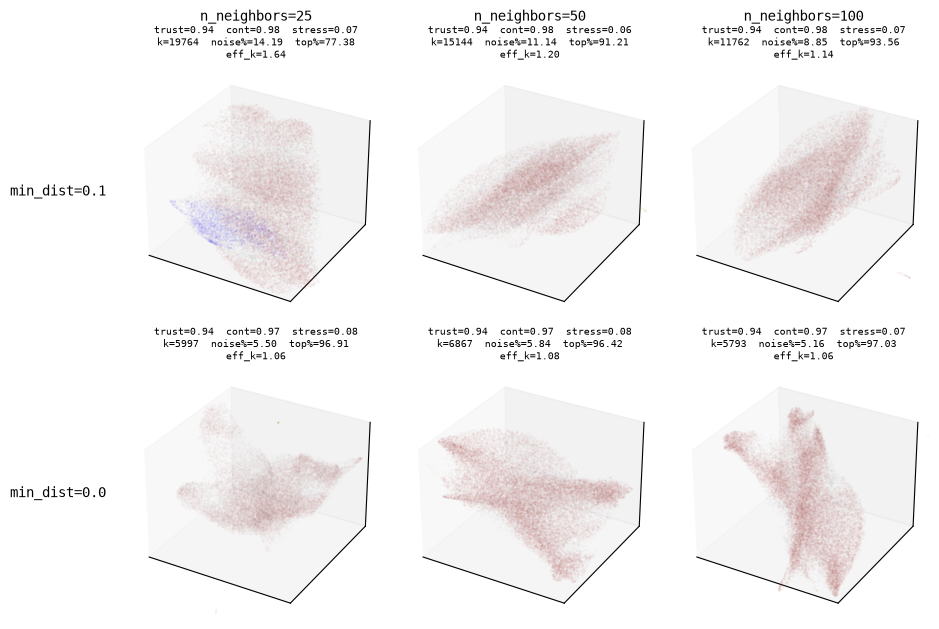

In [16]:
# same axes as the heatmaps above, each cell showing that config's embedding
plot_embedding_grid(results, panels, x="n_neighbors", y="min_dist", alpha=0.2)

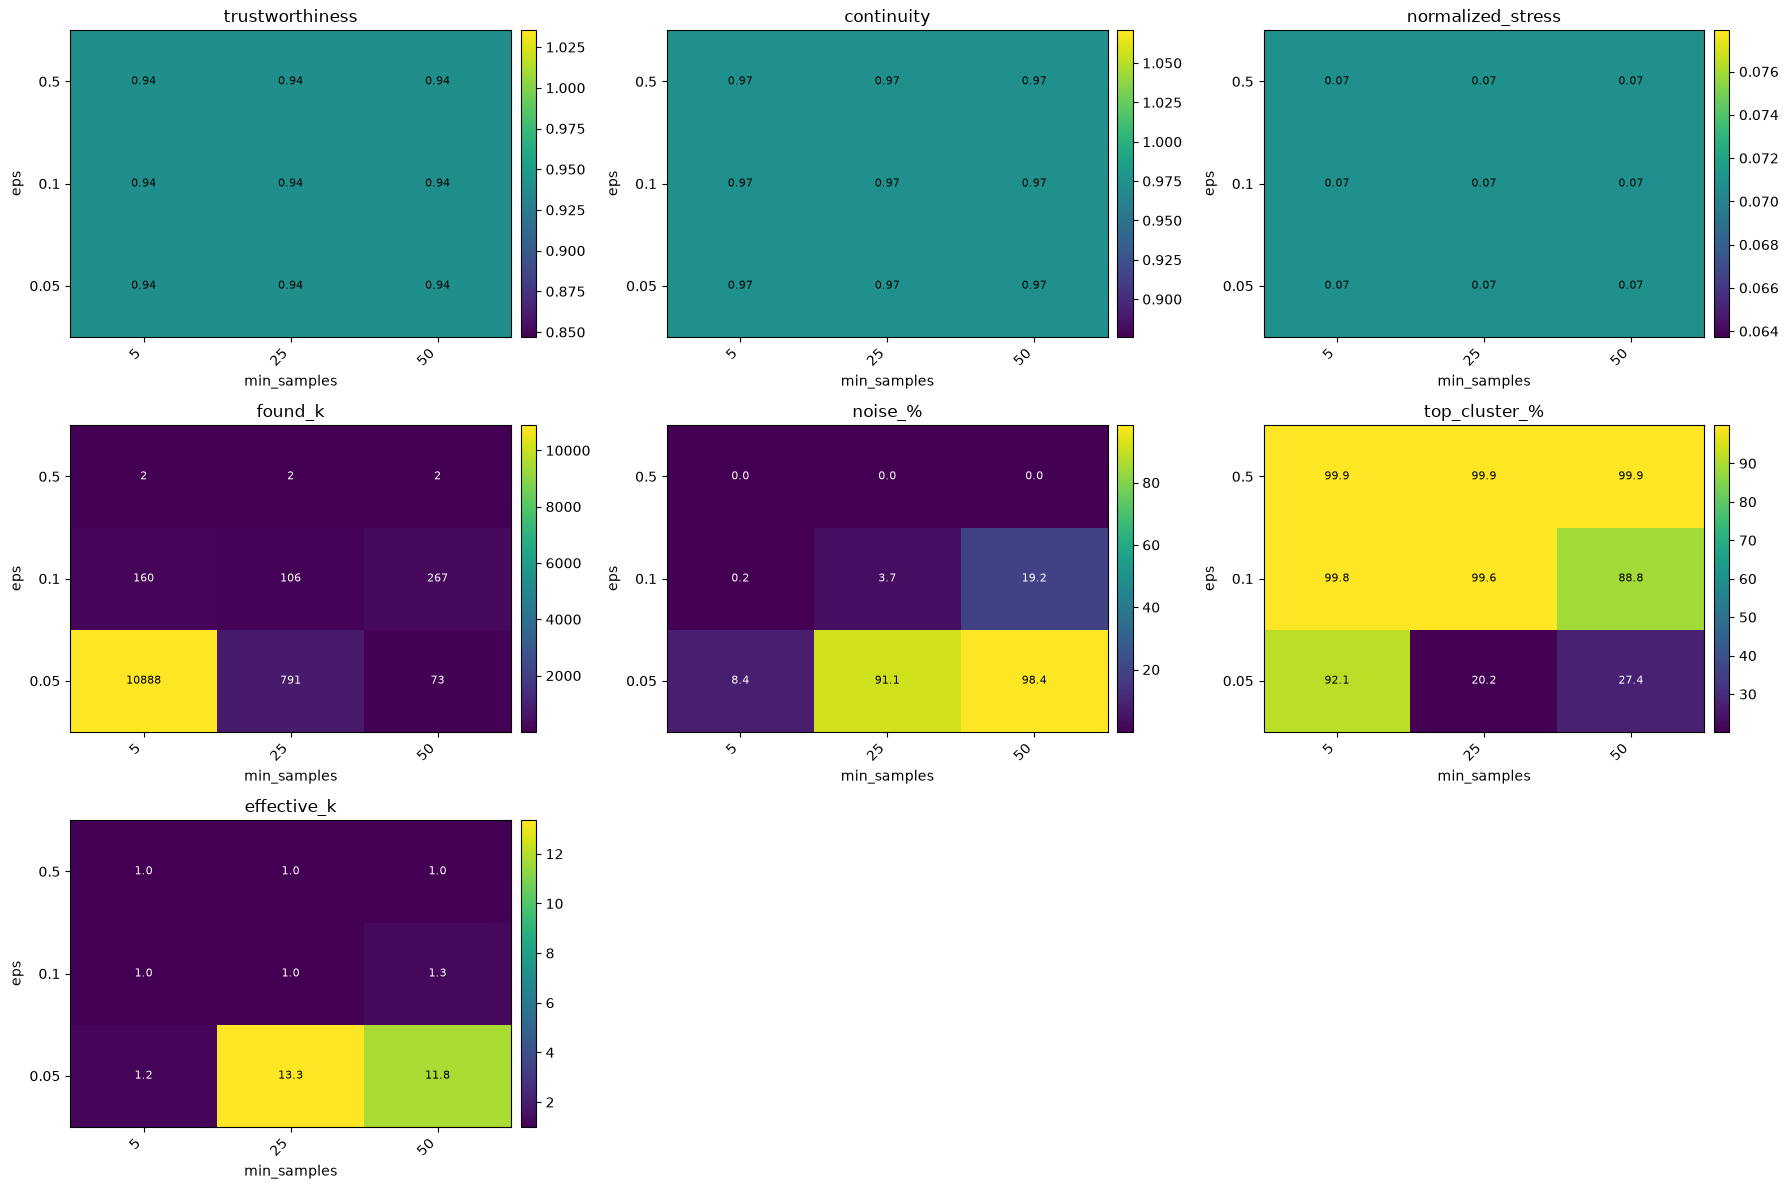

In [17]:
# axes are two swept parameters; one heatmap per metric the sweep recorded
plot_all_metric_heatmaps(results, x="min_samples", y="eps")

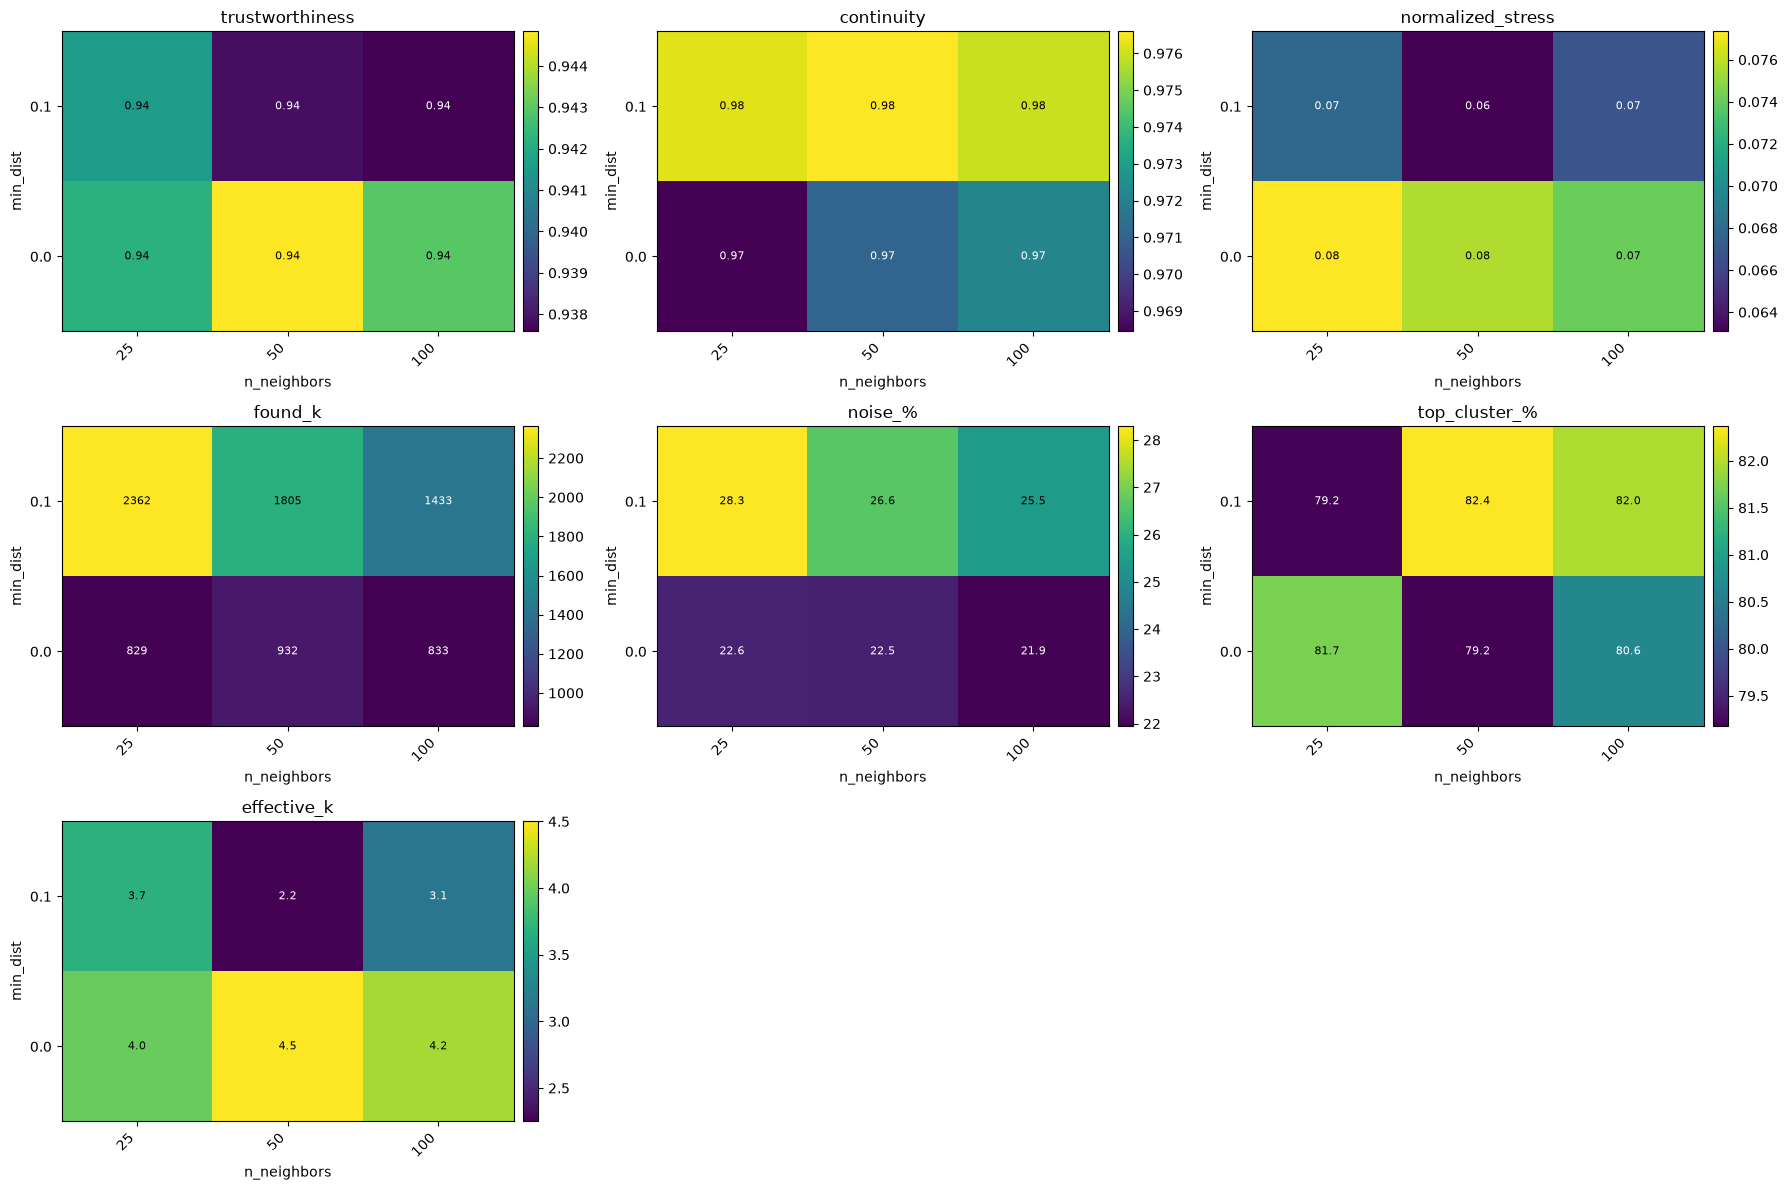

In [18]:
plot_all_metric_heatmaps(results, x="n_neighbors", y="min_dist")

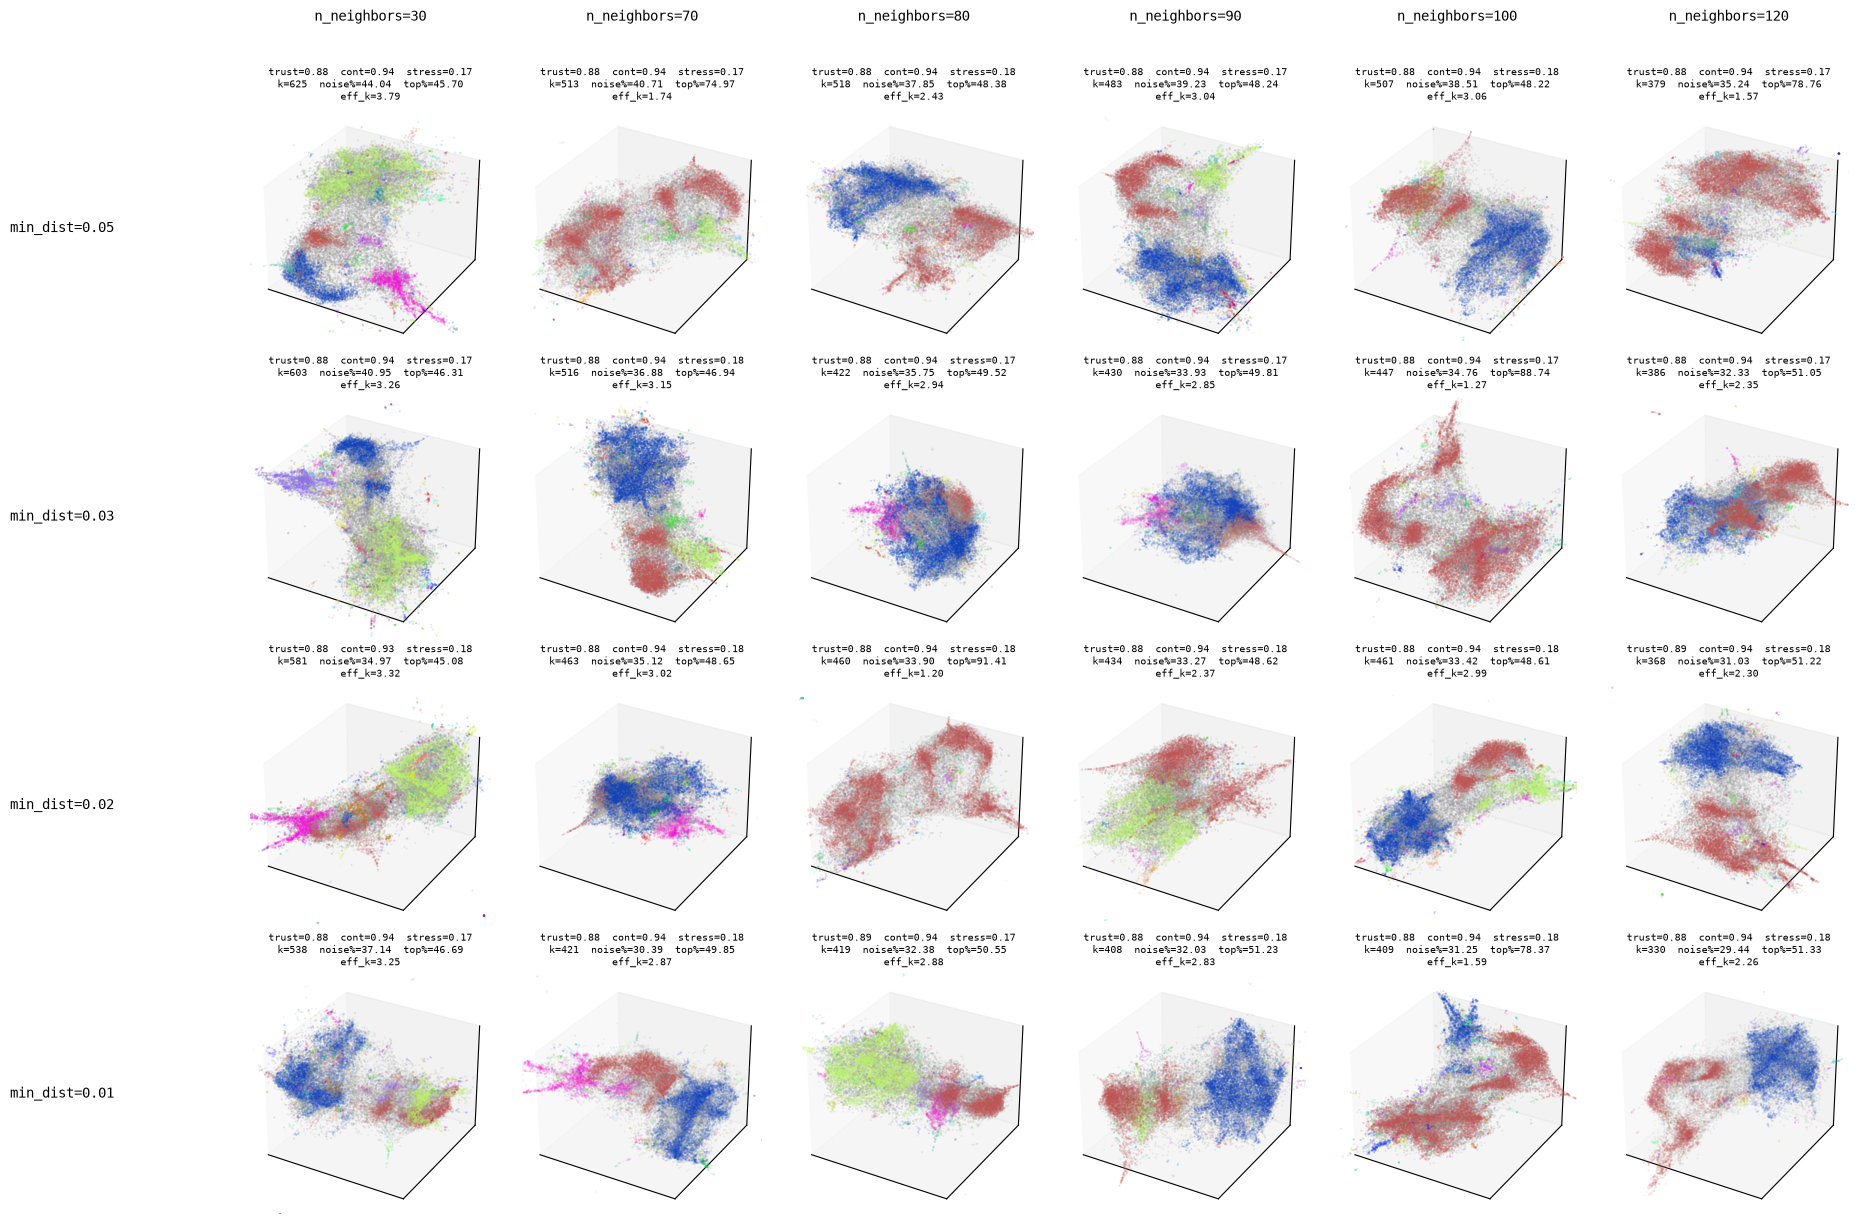

In [20]:
# same axes as the heatmaps above, each cell showing that config's embedding
plot_embedding_grid(results, panels, x="n_neighbors", y="min_dist")

# Sweep with clustering

In [ ]:
def run_umap_sweep(patches, umap_grid, clustering, *,
                   n_members=3, n_components=3, device="gpu",
                   sweep_size=50000, display_subsample=30000,
                   save_path="sweep_results.pkl", seed=0, verbose=True):
    """Sweep UMAP params; per combo run an HDBSCAN ensemble and collect stats
    plus subsampled embeddings for the review grid.

    patches           : (N_patches, D) feature matrix to cluster.
    umap_grid         : {umap_param: [values, ...]} — swept full-factorial.
    clustering        : fixed clustering_dict passed to every NEMI run.
    n_members         : ensemble members per combo.
    n_components      : UMAP output dims.
    sweep_size        : patches per fit (subsample for speed/GPU memory; None = all).
    display_subsample : points kept per embedding panel (None = all).
    save_path         : pickle written after each combo so a crash is resumable.

    Returns (results, panels).  Results align to the subsampled patches — use them
    to rank configs, then re-run the winner on the full patch set.
    """
    rng = np.random.default_rng(seed)
    sweep_idx = (rng.choice(len(patches), size=sweep_size, replace=False)
                 if sweep_size and sweep_size < len(patches) else slice(None))
    sweep_patches = patches[sweep_idx]

    results, panels = [], []
    for umap_params in _umap_configs(umap_grid):
        if verbose:
            print(f"GPU {gpu_used_gb():.2f} GB | host {host_used_gb():.2f} GB | {umap_params}")
        try:
            embedding_dict = {"n_components": n_components, **umap_params}
            nemi = NEMI(params={"device": device,
                                "embedding_dict": embedding_dict,
                                "clustering_dict": clustering})
            nemi.run(sweep_patches, n=n_members, assess_overlap=True)

            clusters, embedding = nemi.clusters, nemi.embedding
            entropy, unassigned = nemi.entropy, nemi.unassigned_frac
            member_counts = [_n_clusters(m.clusters) for m in nemi.nemi_pack]

            stat = {**umap_params,
                    "entropy":           float(np.nanmean(entropy)),
                    "member_abstain_%":  100 * float(np.mean(unassigned)),
                    "consensus_noise_%": 100 * float(np.mean(clusters == -1)),
                    "consensus_k":       _n_clusters(clusters),
                    "member_k_min":      min(member_counts),
                    "member_k_max":      max(member_counts),
                    "member_k_std":      float(np.std(member_counts))}

            if verbose:
                print("=" * 72)
                print(f"UMAP {umap_params}   |   {clustering}")
                print(f"  overall entropy       : {stat['entropy']:.3f}")
                print(f"  member-abstain %      : {stat['member_abstain_%']:.1f}")
                print(f"  consensus-noise %     : {stat['consensus_noise_%']:.1f}")
                print(f"  consensus k           : {stat['consensus_k']}")
                print(f"  per-member k (spread) : {member_counts}  "
                      f"min={stat['member_k_min']} max={stat['member_k_max']} std={stat['member_k_std']:.1f}")

            disp = (rng.choice(len(clusters), size=min(len(clusters), display_subsample), replace=False)
                    if display_subsample else slice(None))
            panels.append({"title": str(umap_params), "emb": np.asarray(embedding)[disp],
                           "clusters": clusters[disp], "entropy": entropy[disp],
                           "unassigned": unassigned[disp]})
            results.append(stat)

            if save_path:
                with open(save_path, "wb") as f:
                    pickle.dump({"results": results, "panels": panels}, f)
        except Exception as e:
            print(f"  !! failed on {umap_params}: {type(e).__name__}: {e}")
        finally:
            nemi = None
            _free_gpu()

    return results, panels

In [ ]:
def show_sweep(results, panels, *, dims=3, sort_by=None, clip_pct=1.0):
    """Review grid (rows = runs; cols = clusters / entropy / unassigned), then a
    stats table.  clip_pct clips each axis to that percentile range to ignore
    outliers (0 = off)."""
    proj    = "3d" if dims == 3 else None
    headers = ["clusters", "entropy", "unassigned"]

    def _frame(ax, pts):
        if clip_pct <= 0:
            return
        setters = [ax.set_xlim, ax.set_ylim] + ([ax.set_zlim] if dims == 3 else [])
        for d, setlim in enumerate(setters):
            lo, hi = np.percentile(pts[:, d], [clip_pct, 100 - clip_pct])
            if hi > lo:
                setlim(lo, hi)

    def _title(p, res):
        return (f"{p['title']}\n"
                f"H={res['entropy']:.2f}  abstain={res['member_abstain_%']:.0f}%  "
                f"noise={res['consensus_noise_%']:.0f}%  k={res['consensus_k']}  "
                f"member_k[{res['member_k_min']}-{res['member_k_max']}]")

    def _scatter(ax, e, c, cmap, norm=None):
        s = ax.scatter(*[e[:, i] for i in range(dims)], c=c, cmap=cmap, norm=norm,
                       s=2, alpha=0.5, linewidths=0)
        _frame(ax, e)
        return s

    # --- review grid ---
    n = len(panels)
    fig, axes = plt.subplots(n, 3, figsize=(16, 5 * n), squeeze=False,
                             subplot_kw={"projection": proj})
    fig.subplots_adjust(left=0.24, hspace=0.25, wspace=0.15)

    for r, (p, res) in enumerate(zip(panels, results)):
        e = p["emb"]
        cmap_c, norm_c = vis._cluster_cmap_norm(p["clusters"])          # discrete, -1 grey
        _scatter(axes[r, 0], e, p["clusters"], cmap_c, norm_c)
        sc1 = _scatter(axes[r, 1], e, p["entropy"], "viridis")
        sc2 = _scatter(axes[r, 2], e, p["unassigned"], "magma")
        fig.colorbar(sc1, ax=axes[r, 1], fraction=0.046, pad=0.02)
        fig.colorbar(sc2, ax=axes[r, 2], fraction=0.046, pad=0.02)
        if r == 0:
            for j in range(3):
                axes[r, j].set_title(headers[j])
        pos = axes[r, 0].get_position()
        fig.text(0.02, pos.y0 + pos.height / 2, _title(p, res),
                 ha="left", va="center", fontsize=9, family="monospace")
    plt.show()

    # --- stats table (no images) ---
    df = pd.DataFrame(results)
    if sort_by and sort_by in df.columns:
        df = df.sort_values(sort_by).reset_index(drop=True)
    display(df.round(3))
    return df

In [31]:
N_MEMBERS = 5
EMBEDDING_DIMENSIONS = 3
DISPLAY_DIMS = 3
DISPLAY_SUBSAMPLE = 30000        # points per scatter (None = plot all)

# fixed HDBSCAN params for every run
CLUSTERING = {"method": "hdbscan", "min_cluster_size": 400, "min_samples": None}

# sweep
UMAP_GRID = {
    "n_neighbors": [2, 50],
    "min_dist":    [0.0, 0.1], 
    "metric":      ["euclidean", "cosine"]
}

# UMAP_GRID = {
#     "n_neighbors": [2, 15, 50],
#     "min_dist":    [0.0, 0.1], 
#     "metric":      ["euclidean", "cosine"]
# }

results, panels = run_umap_sweep(patches, UMAP_GRID, CLUSTERING,
                                 n_members=3, n_components=EMBEDDING_DIMENSIONS,
                                 sweep_size=None)

GPU 1.86 GB | host 5.70 GB | {'n_neighbors': 2, 'min_dist': 0.0, 'metric': 'euclidean'}


  0%|          | 0/3 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-23 22:51:24.359] [CUML] [info] Building knn graph using nn descent
[2026-07-23 22:51:28.765] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


 33%|███▎      | 1/3 [00:20<00:41, 20.72s/it]

Clusters found: 3
Sorting clusters
Fitting the embedding
[2026-07-23 22:51:44.182] [CUML] [info] Building knn graph using nn descent
[2026-07-23 22:51:48.617] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


...

Clusters found: 2
Sorting clusters
Fitting the embedding
[2026-07-23 22:59:07.879] [CUML] [info] Building knn graph using nn descent
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


 67%|██████▋   | 2/3 [00:41<00:20, 20.51s/it]

Clusters found: 2
Sorting clusters
Fitting the embedding
[2026-07-23 22:59:28.286] [CUML] [info] Building knn graph using nn descent
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


100%|██████████| 3/3 [01:01<00:00, 20.40s/it]

Clusters found: 3
Sorting clusters
3 3
UMAP {'n_neighbors': 50, 'min_dist': 0.1, 'metric': 'cosine'}   |   {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}
  overall entropy       : 0.037
  member-abstain %      : 3.5
  consensus-noise %     : 2.5
  consensus k           : 3
  per-member k (spread) : [2, 2, 3]  min=2 max=3 std=0.5


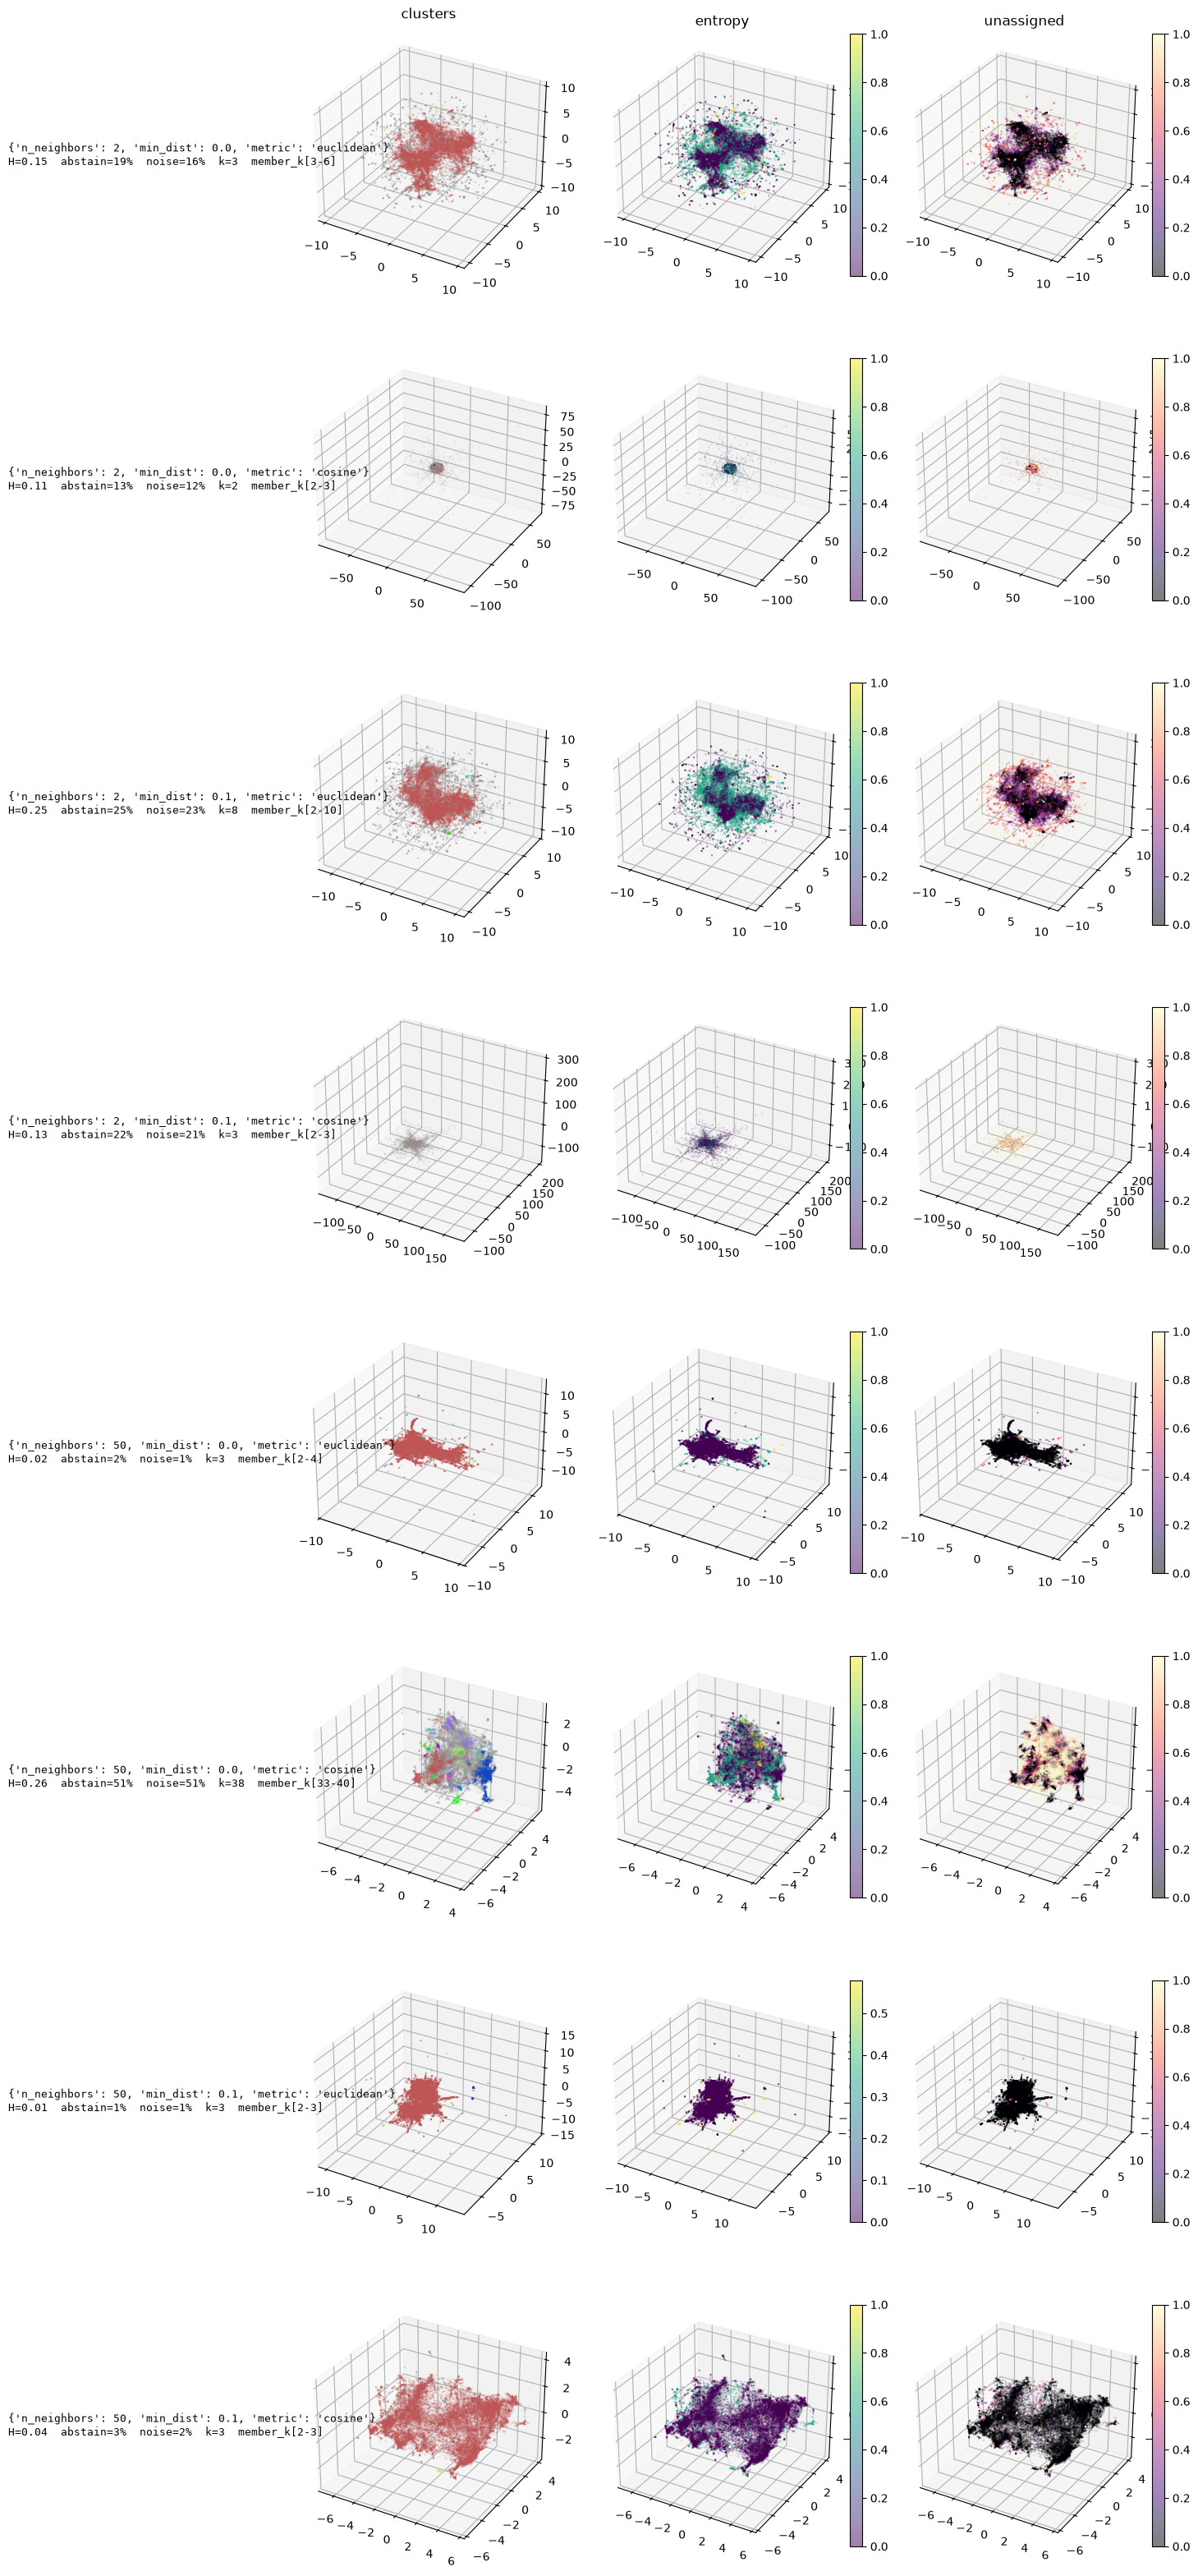

,n_neighbors,min_dist,metric,entropy,member_abstain_%,consensus_noise_%,consensus_k,member_k_min,member_k_max,member_k_std
0,2,0.0,euclidean,0.154,18.998,16.425,3,3,6,1.247
1,2,0.0,cosine,0.115,12.889,11.593,2,2,3,0.471
2,2,0.1,euclidean,0.248,25.438,22.862,8,2,10,3.399
3,2,0.1,cosine,0.130,22.306,20.895,3,2,3,0.471
4,50,0.0,euclidean,0.019,1.682,1.188,3,2,4,0.816
5,50,0.0,cosine,0.263,51.279,51.088,38,33,40,2.944
6,50,0.1,euclidean,0.009,1.127,1.257,3,2,3,0.471
7,50,0.1,cosine,0.037,3.461,2.488,3,2,3,0.471


In [32]:
stats = show_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)
# stats is the DataFrame; e.g. stats.sort_values("entropy") or stats.to_csv("sweep1.csv")

In [21]:
# fixed HDBSCAN params for every run
CLUSTERING = {"method": "hdbscan", "min_cluster_size": 400, "min_samples": None}

# sweep
UMAP_GRID = {
    "n_neighbors": [2, 4, 8, 12], #, 100],
    "min_dist":    [0.0], #, 0.5],
    "metric":      ["euclidean"]
}

results, panels = run_umap_sweep(patches, UMAP_GRID, CLUSTERING,
                                 n_members=5, n_components=EMBEDDING_DIMENSIONS,
                                 sweep_size=None)

GPU 2.19 GB | host 4.71 GB | {'n_neighbors': 2, 'min_dist': 0.0, 'metric': 'euclidean'}


  0%|          | 0/5 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-23 19:12:38.113] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:12:42.417] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


 20%|██        | 1/5 [00:17<01:11, 17.99s/it]

Clusters found: 15
Sorting clusters
Fitting the embedding
[2026-07-23 19:12:55.292] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:12:59.627] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


...

 80%|████████  | 4/5 [01:06<00:16, 16.68s/it]

Clusters found: 24
Sorting clusters
Fitting the embedding
[2026-07-23 19:18:06.778] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:18:11.274] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


100%|██████████| 5/5 [01:23<00:00, 16.72s/it]

Clusters found: 30
Sorting clusters


43 43
UMAP {'n_neighbors': 12, 'min_dist': 0.0, 'metric': 'euclidean'}   |   {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}
  overall entropy       : 0.244
  member-abstain %      : 35.7
  consensus-noise %     : 36.7
  consensus k           : 43
  per-member k (spread) : [43, 37, 43, 24, 30]  min=24 max=43 std=7.4


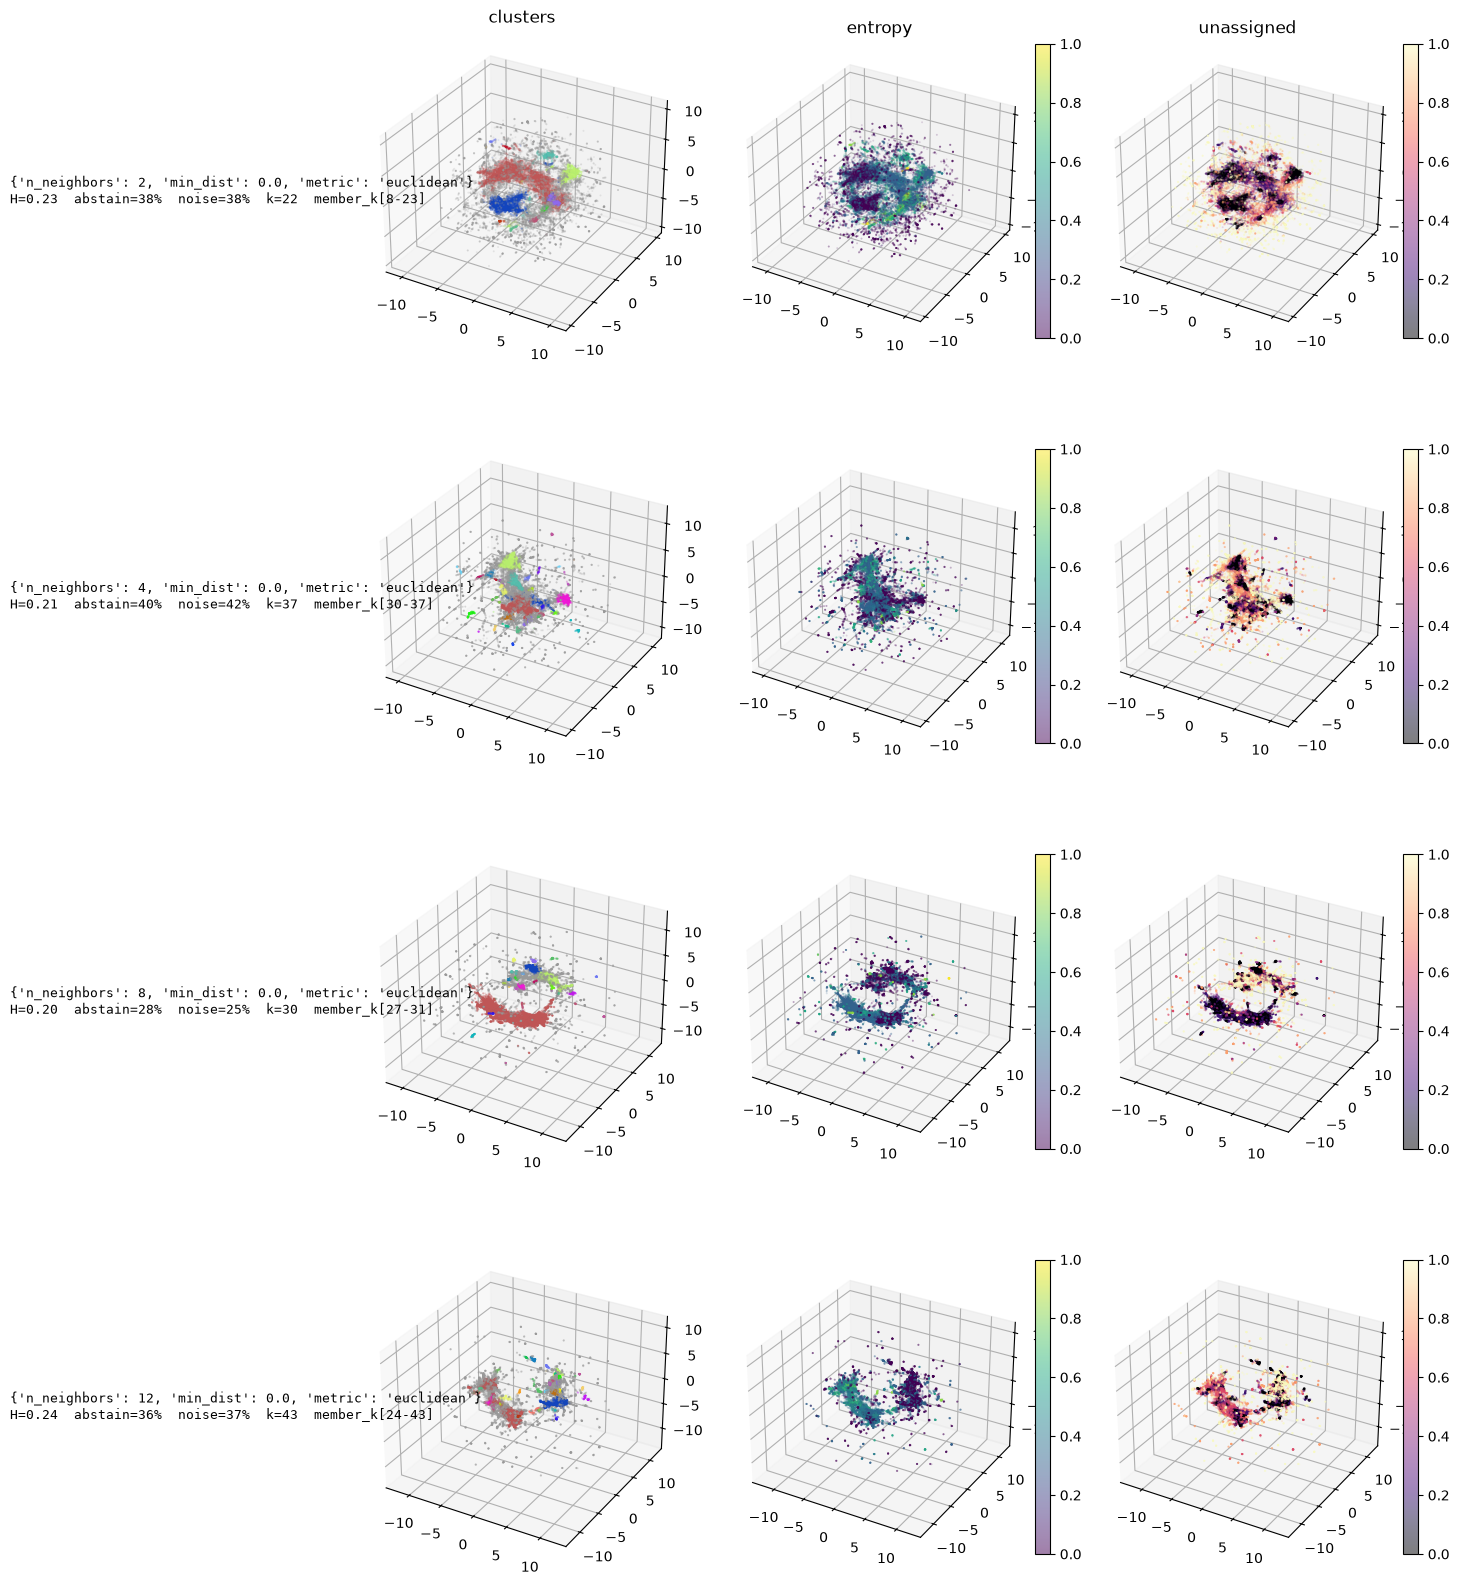

,n_neighbors,min_dist,metric,entropy,member_abstain_%,consensus_noise_%,consensus_k,member_k_min,member_k_max,member_k_std
0,2,0.0,euclidean,0.233,37.821,37.887,22,8,23,5.231
1,4,0.0,euclidean,0.213,39.948,41.961,37,30,37,2.227
2,8,0.0,euclidean,0.204,27.671,24.608,30,27,31,1.625
3,12,0.0,euclidean,0.244,35.711,36.718,43,24,43,7.446


In [22]:
stats = show_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

In [23]:
# fixed HDBSCAN params for every run
CLUSTERING = {"method": "hdbscan", "min_cluster_size": 400, "min_samples": None}

# sweep
UMAP_GRID = {
    "n_neighbors": [7, 8, 9], #, 100],
    "min_dist":    [0.0, 0.05, 0.1], #, 0.5],
    "metric":      ["euclidean"]
}

results, panels = run_umap_sweep(patches, UMAP_GRID, CLUSTERING,
                                 n_members=3, n_components=EMBEDDING_DIMENSIONS,
                                 sweep_size=None)

GPU 1.15 GB | host 4.68 GB | {'n_neighbors': 7, 'min_dist': 0.0, 'metric': 'euclidean'}


  0%|          | 0/5 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-23 19:25:34.646] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:25:38.980] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


 20%|██        | 1/5 [00:16<01:05, 16.32s/it]

Clusters found: 27
Sorting clusters
Fitting the embedding
[2026-07-23 19:25:50.102] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:25:54.532] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


...

 80%|████████  | 4/5 [01:08<00:17, 17.13s/it]

Clusters found: 27
Sorting clusters
Fitting the embedding
[2026-07-23 19:40:08.920] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:40:13.443] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


100%|██████████| 5/5 [01:25<00:00, 17.17s/it]

Clusters found: 25
Sorting clusters


34 34
UMAP {'n_neighbors': 9, 'min_dist': 0.1, 'metric': 'euclidean'}   |   {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}
  overall entropy       : 0.294
  member-abstain %      : 24.6
  consensus-noise %     : 22.9
  consensus k           : 34
  per-member k (spread) : [23, 34, 8, 27, 25]  min=8 max=34 std=8.5


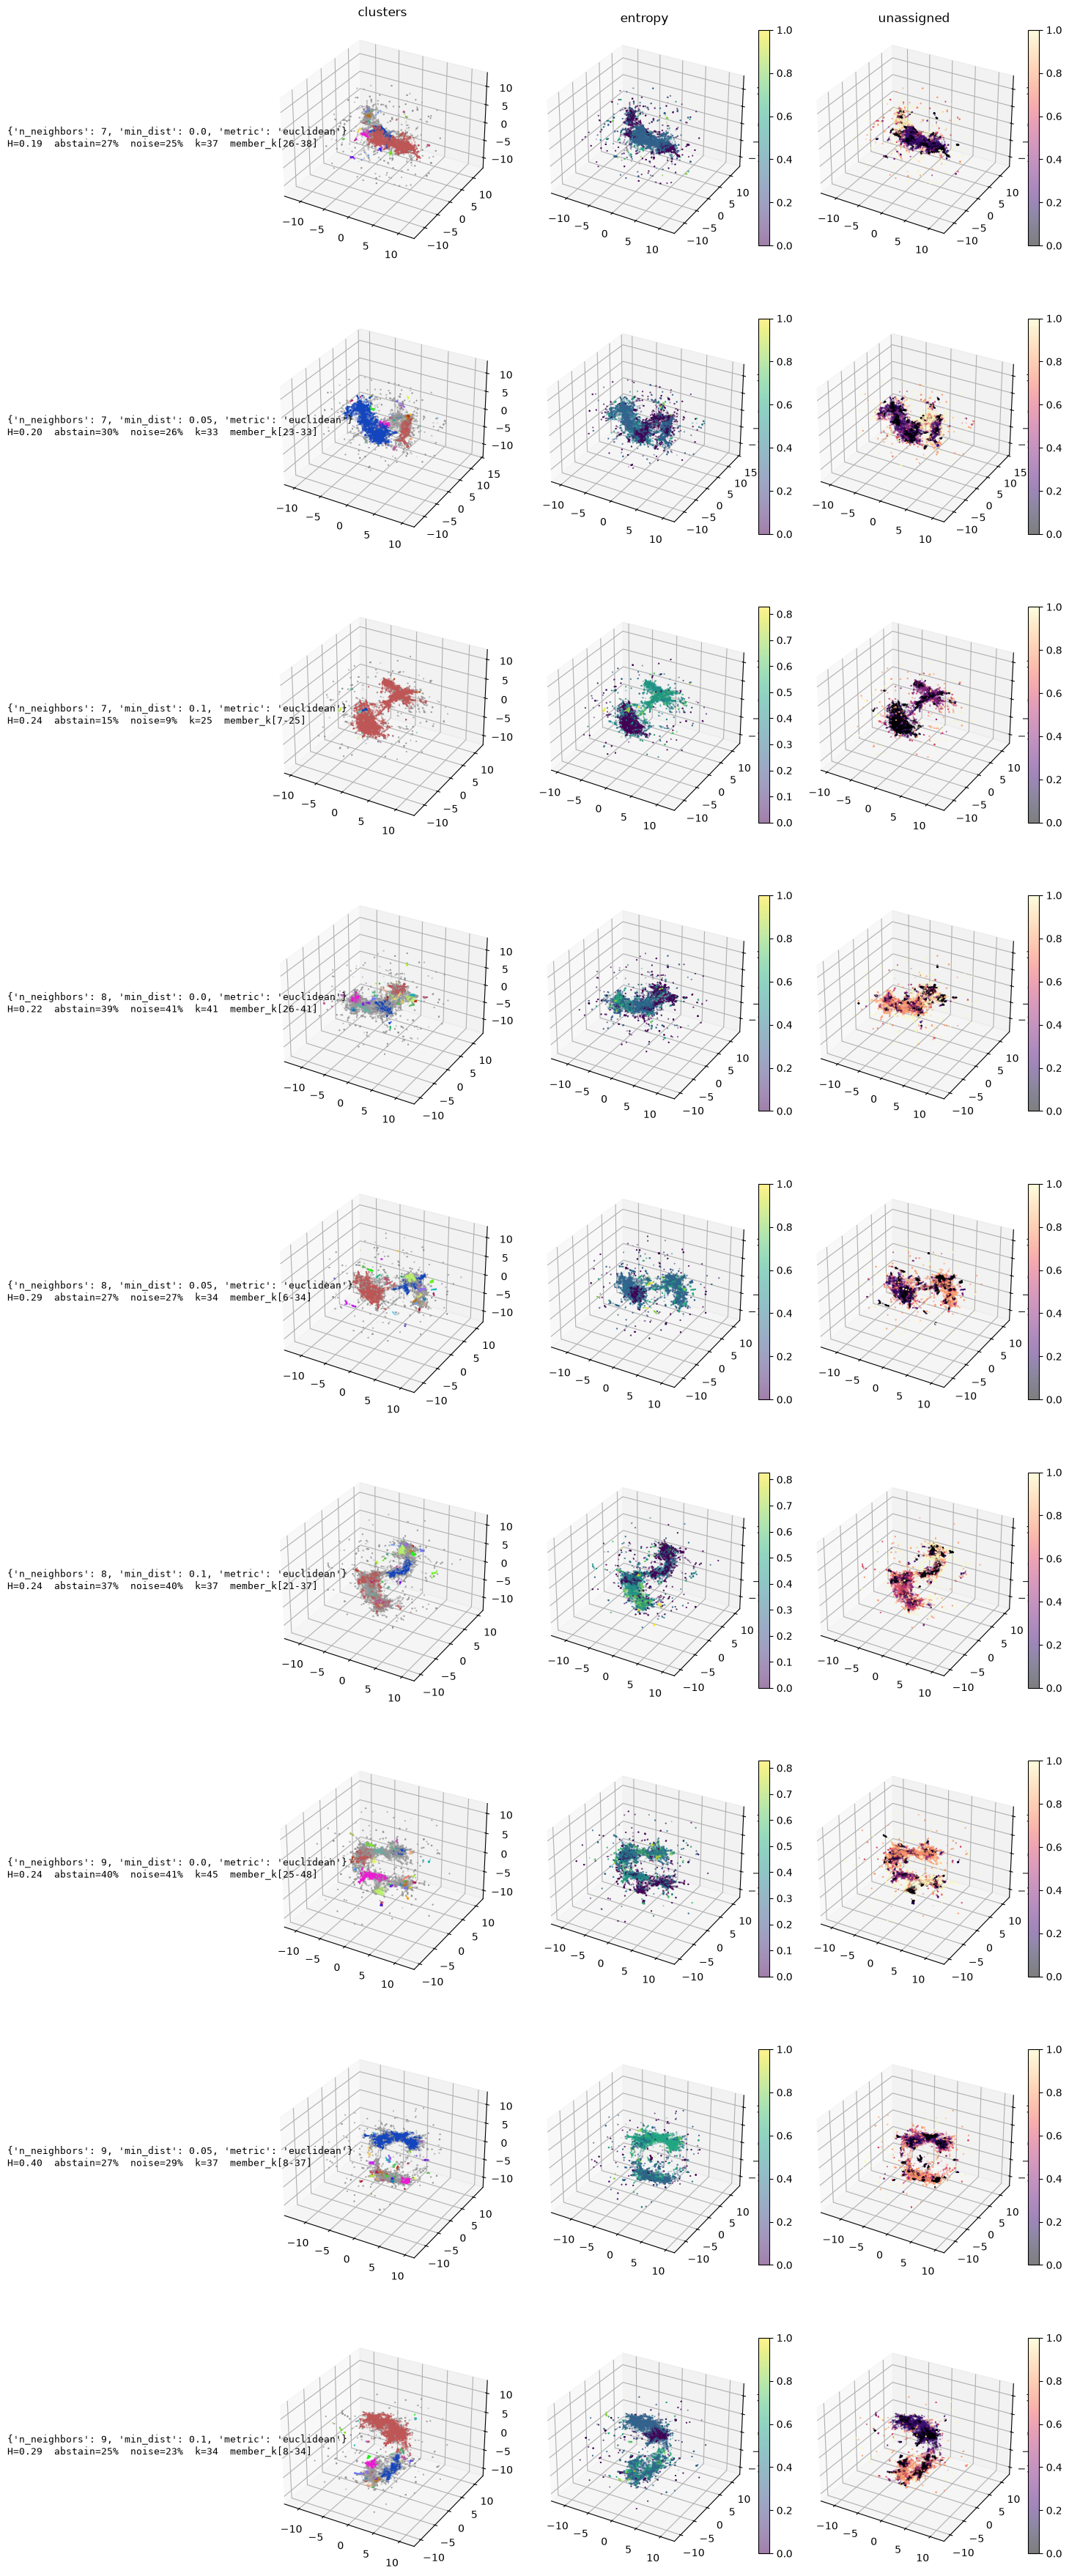

,n_neighbors,min_dist,metric,entropy,member_abstain_%,consensus_noise_%,consensus_k,member_k_min,member_k_max,member_k_std
0,7,0.00,euclidean,0.190,27.274,24.875,37,26,38,4.400
1,7,0.05,euclidean,0.205,29.895,26.016,33,23,33,3.847
2,7,0.10,euclidean,0.237,14.730,9.030,25,7,25,7.823
3,8,0.00,euclidean,0.218,39.126,41.397,41,26,41,5.492
4,8,0.05,euclidean,0.294,26.546,27.084,34,6,34,9.156
5,8,0.10,euclidean,0.236,37.099,39.696,37,21,37,5.987
6,9,0.00,euclidean,0.241,39.614,41.419,45,25,48,7.965
7,9,0.05,euclidean,0.404,27.332,29.245,37,8,37,9.790
8,9,0.10,euclidean,0.294,24.586,22.945,34,8,34,8.546


In [24]:
stats = show_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)